# Kapitel 3 - Koduppgift 13

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# läs in data
df = pd.read_excel("hr_employee_data.xlsx")

In [3]:
# printa ut info

print("Första 5 raderna")
print(df.head())
print()

print("Shape")
print(df.shape)
print()

print("Kolumner")
print(df.columns.tolist())
print()

print("Datatyper")
print(df.dtypes)
print()

print("Saknade värden")
print(df.isnull().sum())
print()


Första 5 raderna
     Emp_Id  satisfaction_level  last_evaluation  number_project  \
0  IND02438                0.38             0.53               2   
1  IND28133                0.80             0.86               5   
2  IND07164                0.11             0.88               7   
3  IND30478                0.72             0.87               5   
4  IND24003                0.37             0.52               2   

   average_montly_hours  time_spend_company  Work_accident  left  \
0                   157                   3              0     1   
1                   262                   6              0     1   
2                   272                   4              0     1   
3                   223                   5              0     1   
4                   159                   3              0     1   

   promotion_last_5years Department  salary  
0                      0      sales     low  
1                      0      sales  medium  
2                      0   

In [4]:
# Andel som slutar 

attrition_rate = df["left"].mean() * 100
print(f"Andel som har slutat: {attrition_rate:.2f}%\n")

# Lönefördelning
print("Lönefördelning")
print(df["salary"].value_counts(), "\n")

# Avdelning
print("Avdelningar")
print(df["Department"].value_counts(), "\n")

#Jämförelse mellan stannat/slutat
print("Jämförelse mellan stannat/slutat")
print(df.groupby("left")[[
    "satisfaction_level",
    "last_evaluation",
    "number_project",
    "average_montly_hours",
    "time_spend_company"
]].mean(), "\n")



Andel som har slutat: 23.81%

Lönefördelning
salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64 

Avdelningar
Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64 

Jämförelse mellan stannat/slutat
      satisfaction_level  last_evaluation  number_project  \
left                                                        
0               0.666810         0.715473        3.786664   
1               0.440098         0.718113        3.855503   

      average_montly_hours  time_spend_company  
left                                            
0               199.060203            3.380032  
1               207.419210            3.876505   



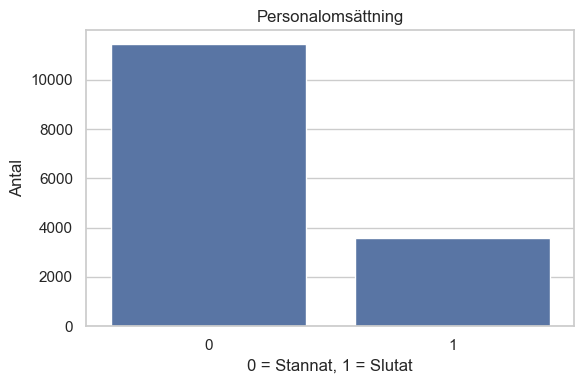

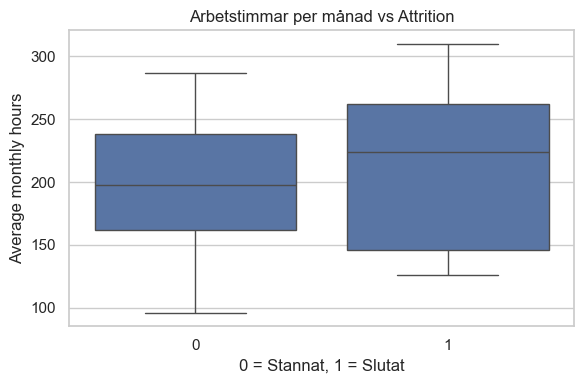

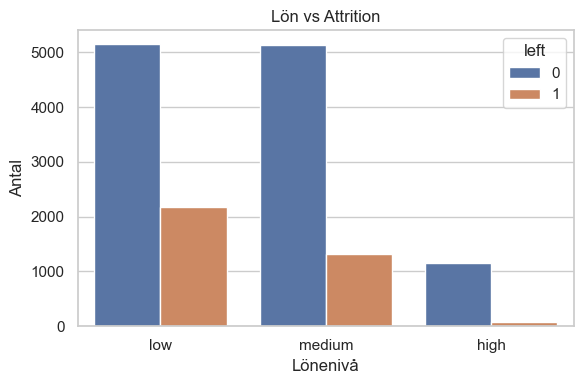

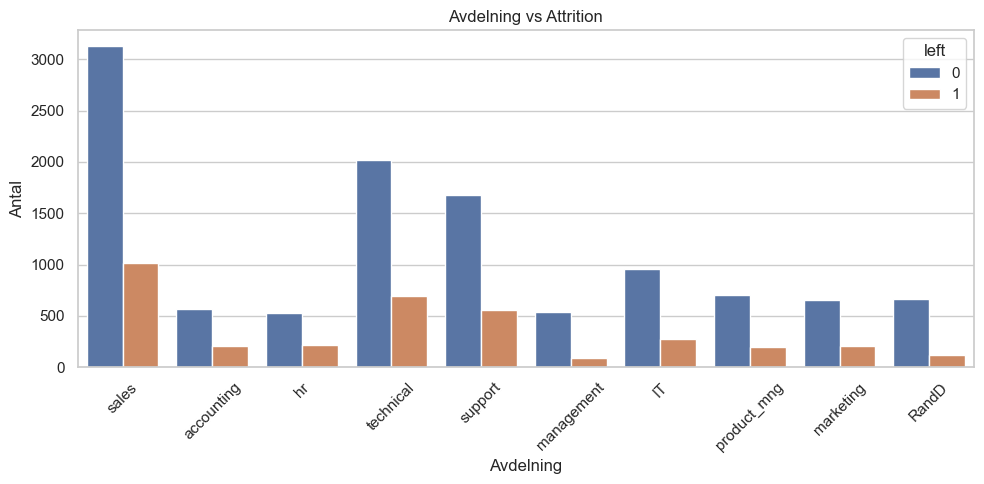

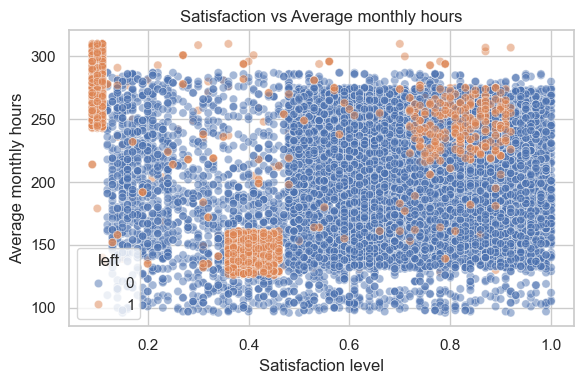

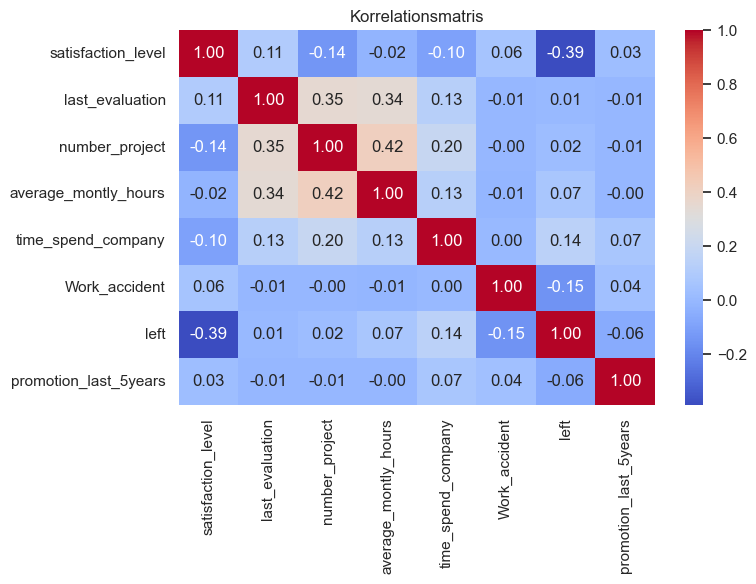

In [5]:
# Visualiseringar

sns.set(style="whitegrid")

# Personalomsättning
plt.figure(figsize=(6, 4))
sns.countplot(x="left", data=df)
plt.title("Personalomsättning")
plt.xlabel("0 = Stannat, 1 = Slutat")
plt.ylabel("Antal")
plt.tight_layout()
plt.show()

#Arbetstimmar vs attrition
plt.figure(figsize=(6, 4))
sns.boxplot(x="left", y="average_montly_hours", data=df)
plt.title("Arbetstimmar per månad vs Attrition")
plt.xlabel("0 = Stannat, 1 = Slutat")
plt.ylabel("Average monthly hours")
plt.tight_layout()
plt.show()

#Lön vs attrition
plt.figure(figsize=(6, 4))
sns.countplot(x="salary", hue="left", data=df)
plt.title("Lön vs Attrition")
plt.xlabel("Lönenivå")
plt.ylabel("Antal")
plt.tight_layout()
plt.show()

#Avdelning vs attrition
plt.figure(figsize=(10, 5))
sns.countplot(x="Department", hue="left", data=df)
plt.title("Avdelning vs Attrition")
plt.xlabel("Avdelning")
plt.ylabel("Antal")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Scatterplot: satisfaction vs hours
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x="satisfaction_level",
    y="average_montly_hours",
    hue="left",
    data=df,
    alpha=0.5
)
plt.title("Satisfaction vs Average monthly hours")
plt.xlabel("Satisfaction level")
plt.ylabel("Average monthly hours")
plt.tight_layout()
plt.show()

#Korrelationsmatris
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korrelationsmatris")
plt.tight_layout()
plt.show()